<img src="img/logoitqv1.jpg" width="500">
<br>

# Ejercicio Práctico

## Normalización y Estandarización de Datos en Inteligencia Artificial
<br>

<img src="img/python_logo.png" width="300">
<br>

*Jesús Viera* https://github.com/Vierita23/machinelearning

# 1. Ejercicio Práctico



## 2. Práctica Académica
### Normalización y Estandarización de Datos en Inteligencia Artificial

Análisis y aplicación de técnicas de normalización y estandarización en un conjunto de datos para modelos de aprendizaje automático.

### Objetivo General

Aplicar técnicas de normalización y estandarización de datos mediante herramientas de Python, con el fin de comprender su impacto en la preparación de datos y en el desempeño de modelos de aprendizaje automático.

### Objetivos específicos
- Identificar diferencias de escala entre variables numéricas.
- Aplicar técnicas de normalización (Min-Max).
- Aplicar técnicas de estandarización (Z-score).
- Analizar la importancia del preprocesamiento en modelos de IA.

### Antecedentes / Fundamentación teórica

En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados poco confiables. Para mitigar este problema, se emplean técnicas como:

- **Normalización:** transforma los datos a un rango específico (generalmente [0,1]).
- **Estandarización:** ajusta los datos para que tengan media 0 y desviación estándar 1.

Estas técnicas son fundamentales en algoritmos como: **KNN**, **Regresión logística** y **Redes neuronales**.

### Escenario de práctica

Una empresa de análisis de datos desea desarrollar modelos predictivos utilizando información de clientes. Sin embargo, se ha identificado que las variables presentan diferentes escalas, lo que puede afectar el rendimiento de los modelos. Se solicita al analista aplicar técnicas de preprocesamiento y limpieza de datos para mejorar la calidad de los datos.

### Conjunto de datos a utilizar
- **Dataset 1 (conceptual):** Iris dataset
- **Dataset 2 (aplicación real):** California Housing Dataset

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
# from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [2]:
# Configuramos el entorno de descarga (carpeta donde esta el token kaggle.json)
import os
os.environ['KAGGLE_CONFIG_DIR'] = "C:/Users/Jesus/.kaggle"

In [3]:
# Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [4]:
# Descargamos el dataset desde Kaggle (si falla, usaremos el CSV local)
try:
    import kaggle
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files("uciml/iris", path=".", unzip=False)
    print("Dataset descargado desde Kaggle")
except Exception as e:
    print("No se pudo descargar desde Kaggle, se usara el dataset local:", e)

Dataset URL: https://www.kaggle.com/datasets/uciml/iris


Dataset descargado desde Kaggle


In [5]:
# Descomprimimos el archivo (si existe el zip descargado)
if os.path.exists("iris.zip"):
    with zipfile.ZipFile("iris.zip", "r") as zip_ref:
        zip_ref.extractall("dataset")
    print("Archivo descomprimido en la carpeta 'dataset'")
else:
    print("No se encontro iris.zip; se usara el dataset/Iris.csv existente")

Archivo descomprimido en la carpeta 'dataset'


In [6]:
# Cargamos el conjunto de datos
df = pd.read_csv("dataset/Iris.csv")

In [7]:
# Mostramos el conjunto de datos
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
# Eliminamos columnas innecesarias en la limpieza de datos: la columna 'Id'
# no aporta nada a nuestro modelo, por lo tanto la eliminamos
if 'Id' in df.columns:
    df = df.drop(columns=["Id"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
# Mostramos los detalles de nuestro dataset
df.info()
# Verificamos si tenemos datos nulos; si los hay, los sumamos
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [10]:
# Separamos los datos de entrada de nuestra variable objetivo
X = df.drop(columns=['Species'])
y = df['Species']

In [11]:
# Exploramos (analisis exploratorio) del conjunto de datos
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Conclusión

Cuando observamos la tabla, lo primero que se nota es que cada variable tiene valores diferentes en tamaño y rango. Por ejemplo:

- **PetalLengthCm** tiene valores desde 1.0 hasta 6.9, lo que significa que varía bastante.
- En cambio, **SepalWidthCm** va aproximadamente de 2.0 a 4.4, es decir, tiene menor variación.

Esto nos dice que **no todas las variables están en la misma escala**.

**¿Qué significa?** En modelos como KNN, los números grandes "pesan más" e influyen más en el resultado. Si no hacemos nada, el modelo tomaría decisiones basadas sobre todo en `PetalLengthCm` y menos en las demás variables. Esto no es lo conveniente y se llama **sesgo**.

Para evitar el sesgo aplicamos **Normalización** y **Estandarización**, que permiten que todas las variables estén en la misma escala y tengan la misma importancia.

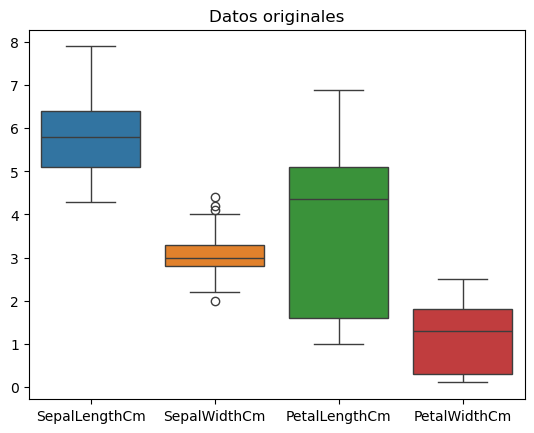

In [12]:
# Dibujamos los datos originales
sns.boxplot(data=X)
# Ponemos un titulo a la imagen
plt.title("Datos originales")
plt.show()

### Interpretación de la imagen

Este gráfico nos permite observar que los datos no están en la misma escala y que algunas variables tienen mayor variabilidad que otras. Esto puede afectar el comportamiento de los modelos de inteligencia artificial, por lo que es necesario aplicar técnicas como la normalización o estandarización para equilibrar la influencia de todas las variables.

In [13]:
# Normalizamos el conjunto de datos (Min-Max -> rango [0,1])
normalizer = preprocessing.MinMaxScaler()
X_norm = normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [14]:
# Resumen estadistico de los datos normalizados (min=0, max=1)
X_norm.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [15]:
# Estandarización (Z-score -> media 0 y desviacion 1)
standarizer = preprocessing.StandardScaler()
# Estandarizamos los datos
X_std = standarizer.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns)
X_std.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


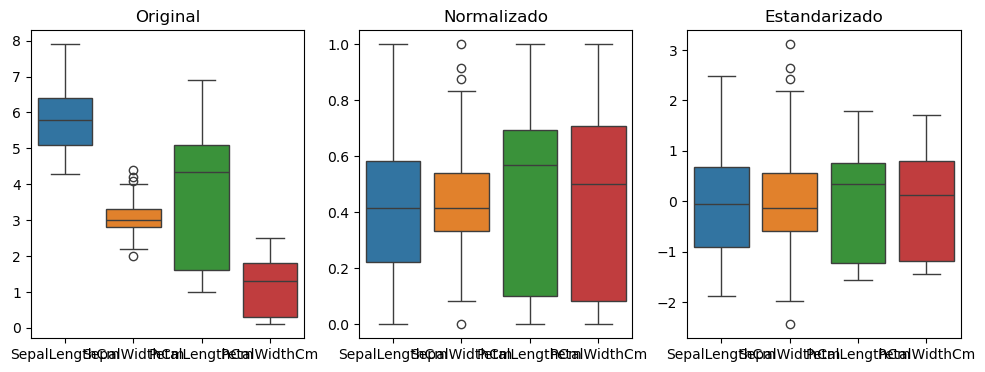

In [16]:
# Comparación visual de los tres estados de los datos
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(data=X)
plt.title("Original")

plt.subplot(1, 3, 2)
sns.boxplot(data=X_norm)
plt.title("Normalizado")

plt.subplot(1, 3, 3)
sns.boxplot(data=X_std)
plt.title("Estandarizado")

plt.show()

# 4. Dataset 2: California Housing (aplicación real)

Ahora aplicamos las mismas técnicas de **normalización** y **estandarización** sobre un conjunto de datos real: el **California Housing Dataset**, que contiene información de viviendas de California (ingresos, número de habitaciones, población, etc.). Es un caso ideal porque sus variables tienen escalas muy distintas.

In [2]:
# Cargamos el California Housing Dataset desde sklearn
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
df_cal = california.frame
df_cal.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Revisamos la informacion general del dataset
df_cal.info()
# Verificamos si hay valores nulos
df_cal.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [4]:
# Separamos las variables de entrada (X2) de la variable objetivo (MedHouseVal)
X2 = df_cal.drop(columns=["MedHouseVal"])
y2 = df_cal["MedHouseVal"]
X2.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


### Observación de las escalas

Al mirar el `describe()` se nota claramente el problema: por ejemplo, `Population` llega a valores de miles, mientras que `AveRooms` o `MedInc` manejan números mucho más pequeños. Esa diferencia tan grande de escala haría que las variables con números altos dominen el modelo. Por eso necesitamos normalizar o estandarizar.

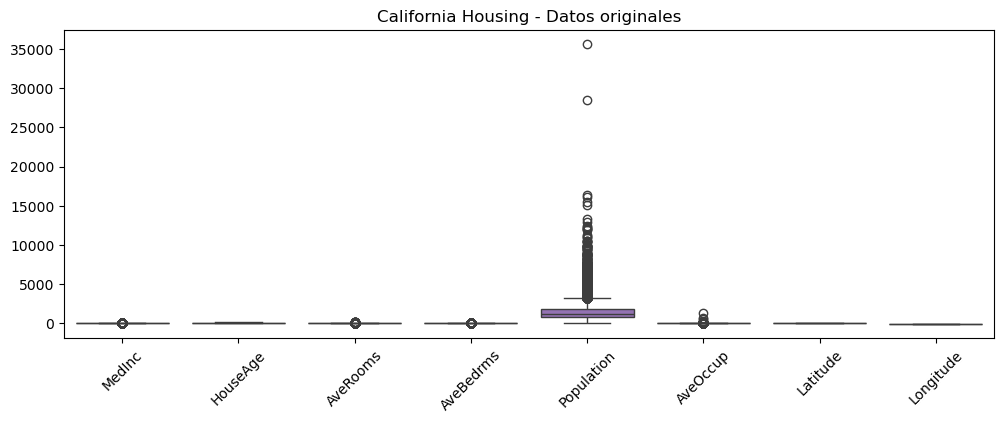

In [5]:
# Dibujamos los datos originales (rotamos las etiquetas porque son varias variables)
plt.figure(figsize=(12, 4))
sns.boxplot(data=X2)
plt.title("California Housing - Datos originales")
plt.xticks(rotation=45)
plt.show()

In [6]:
# Normalizamos el conjunto de datos (Min-Max -> rango [0,1])
normalizer_cal = preprocessing.MinMaxScaler()
X2_norm = normalizer_cal.fit_transform(X2)
X2_norm = pd.DataFrame(X2_norm, columns=X2.columns)
X2_norm.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163


In [7]:
# Resumen estadistico de los datos normalizados (min=0, max=1)
X2_norm.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,0.232464,0.541951,0.032488,0.022629,0.039869,0.001914,0.328572,0.476125
std,0.131020,0.246776,0.017539,0.014049,0.031740,0.008358,0.226988,0.199555
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142308,0.333333,0.025482,0.019943,0.021974,0.001398,0.147715,0.253984
50%,0.209301,0.549020,0.031071,0.021209,0.032596,0.001711,0.182784,0.583665
75%,0.292641,0.705882,0.036907,0.022713,0.048264,0.002084,0.549416,0.631474
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# Estandarizacion (Z-score -> media 0 y desviacion 1)
standarizer_cal = preprocessing.StandardScaler()
X2_std = standarizer_cal.fit_transform(X2)
X2_std = pd.DataFrame(X2_std, columns=X2.columns)
X2_std.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


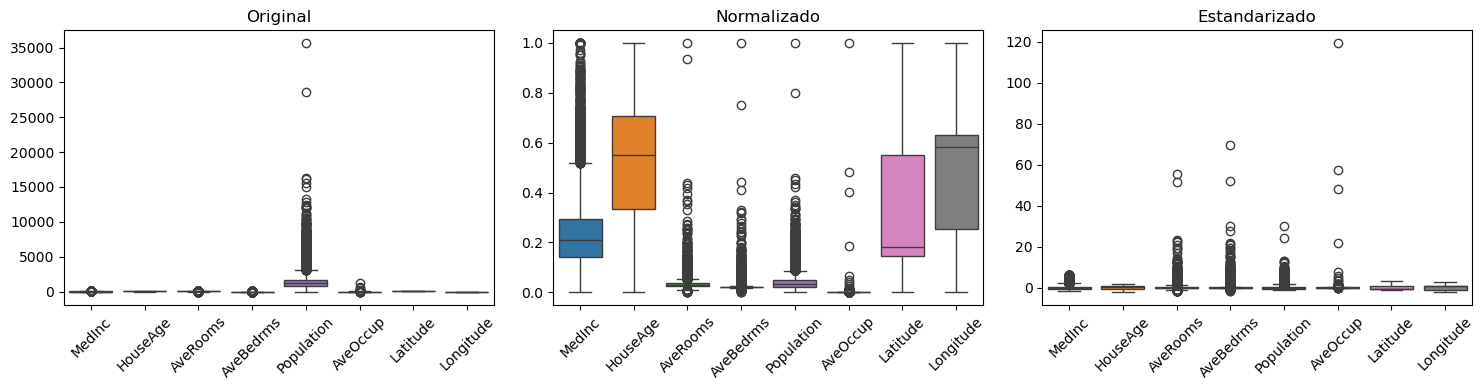

In [9]:
# Comparacion visual de los tres estados de los datos
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(data=X2)
plt.title("Original")
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.boxplot(data=X2_norm)
plt.title("Normalizado")
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.boxplot(data=X2_std)
plt.title("Estandarizado")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Conclusión final

Con ambos datasets (Iris y California Housing) se comprueba lo mismo: los datos originales tienen escalas muy diferentes, lo que puede sesgar los modelos.

- La **normalización (Min-Max)** dejó todas las variables en el rango [0,1].
- La **estandarización (Z-score)** las dejó con media 0 y desviación 1.

Aplicar estas técnicas antes de entrenar es fundamental en algoritmos sensibles a la escala como **KNN**, **regresión logística** y **redes neuronales**, ya que permite que todas las variables aporten de forma equilibrada y se obtengan mejores resultados.